<a href="https://colab.research.google.com/github/najiibnuharis/Milege-Prediction/blob/main/Fifa_World_cup_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sklearn as sklearn

In [ ]:
matches_df= pd.read_csv("WorldCupMatches.csv")
world_cups_df= pd.read_csv("WorldCups.csv")


In [ ]:
# Sample of worldcupmatches
print("Sample of matches_df:")
print(matches_df.head())

#sample of world_cups_df
print("\nSample of world_cups_df:")
print(world_cups_df.head())

Sample of matches_df:
     Year              Datetime    Stage         Stadium         City  \
0  1930.0  13 Jul 1930 - 15:00   Group 1         Pocitos  Montevideo    
1  1930.0  13 Jul 1930 - 15:00   Group 4  Parque Central  Montevideo    
2  1930.0  14 Jul 1930 - 12:45   Group 2  Parque Central  Montevideo    
3  1930.0  14 Jul 1930 - 14:50   Group 3         Pocitos  Montevideo    
4  1930.0  15 Jul 1930 - 16:00   Group 1  Parque Central  Montevideo    

  Home Team Name  Home Team Goals  Away Team Goals Away Team Name  \
0         France              4.0              1.0         Mexico   
1            USA              3.0              0.0        Belgium   
2     Yugoslavia              2.0              1.0         Brazil   
3        Romania              3.0              1.0           Peru   
4      Argentina              1.0              0.0         France   

  Win conditions  Attendance  Half-time Home Goals  Half-time Away Goals  \
0                     4444.0                   3

In [ ]:
matches_df.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


In [ ]:
world_cups_df.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1.045.246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768.607


In [ ]:
matches_shape = matches_df.shape
print("Shape of Matches Dataset:", matches_shape)

Shape of Matches Dataset: (4572, 20)


In [ ]:
world_cups_shape = world_cups_df.shape
print("Shape of world_cups_df:", world_cups_shape)

Shape of world_cups_df: (20, 10)


In [ ]:
#Data Cleaning
print("Info of matches_df:")
matches_df.info()



Info of matches_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    float64
 1   Datetime              852 non-null    object 
 2   Stage                 852 non-null    object 
 3   Stadium               852 non-null    object 
 4   City                  852 non-null    object 
 5   Home Team Name        852 non-null    object 
 6   Home Team Goals       852 non-null    float64
 7   Away Team Goals       852 non-null    float64
 8   Away Team Name        852 non-null    object 
 9   Win conditions        852 non-null    object 
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    float64
 12  Half-time Away Goals  852 non-null    float64
 13  Referee               852 non-null    object 
 14  Assistant 1           852 non-null    object 
 15  A

In [ ]:
print("\nInfo of world_cups_df:")
world_cups_df.info()


Info of world_cups_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            20 non-null     int64 
 1   Country         20 non-null     object
 2   Winner          20 non-null     object
 3   Runners-Up      20 non-null     object
 4   Third           20 non-null     object
 5   Fourth          20 non-null     object
 6   GoalsScored     20 non-null     int64 
 7   QualifiedTeams  20 non-null     int64 
 8   MatchesPlayed   20 non-null     int64 
 9   Attendance      20 non-null     object
dtypes: int64(4), object(6)
memory usage: 1.7+ KB


In [ ]:
# Identify unique values in relevant columns
unique_home_teams = matches_df['Home Team Name'].unique()
unique_away_teams = matches_df['Away Team Name'].unique()

print("Unique Home Teams:")
print(unique_home_teams)
print("\nUnique Away Teams:")
print(unique_away_teams)

Unique Home Teams:
['France' 'USA' 'Yugoslavia' 'Romania' 'Argentina' 'Chile' 'Uruguay'
 'Brazil' 'Paraguay' 'Austria' 'Hungary' 'Switzerland' 'Sweden' 'Germany'
 'Spain' 'Italy' 'Czechoslovakia' 'Cuba' 'England' 'Germany FR' 'Turkey'
 'Soviet Union' 'Northern Ireland' 'Mexico' 'Wales' 'Portugal' 'Korea DPR'
 'Peru' 'Belgium' 'Bulgaria' 'German DR' 'Zaire' 'Poland' 'Australia'
 'Scotland' 'Netherlands' 'Haiti' 'Tunisia' 'Algeria' 'Honduras' 'Canada'
 'Morocco' 'Korea Republic' 'Iraq' 'Denmark' 'rn">United Arab Emirates'
 'Costa Rica' 'Cameroon' 'rn">Republic of Ireland' 'Colombia' 'Norway'
 'Nigeria' 'Saudi Arabia' 'Bolivia' 'Russia' 'Greece' 'Jamaica'
 'South Africa' 'Japan' 'Croatia' 'China PR' 'Senegal' 'Slovenia'
 'Ecuador' 'rn">Trinidad and Tobago' 'rn">Serbia and Montenegro' 'Angola'
 'Czech Republic' 'Togo' 'Iran' "C�te d'Ivoire" 'Ghana' 'Ukraine' 'Serbia'
 'New Zealand' 'Slovakia' 'IR Iran' 'rn">Bosnia and Herzegovina' nan]

Unique Away Teams:
['Mexico' 'Belgium' 'Brazil' 'Peru

In [ ]:
unique_years = world_cups_df['Year'].unique()
print("Unique Years in World Cups Dataset:")
print(unique_years)

# Identify unique values in other relevant columns
unique_winners = world_cups_df['Winner'].unique()
unique_runners_up = world_cups_df['Runners-Up'].unique()


print("\nUnique Winners:")
print(unique_winners)
print("\nUnique Runners-Up:")
print(unique_runners_up)

Unique Years in World Cups Dataset:
[1930 1934 1938 1950 1954 1958 1962 1966 1970 1974 1978 1982 1986 1990
 1994 1998 2002 2006 2010 2014]

Unique Winners:
['Uruguay' 'Italy' 'Germany FR' 'Brazil' 'England' 'Argentina' 'France'
 'Spain' 'Germany']

Unique Runners-Up:
['Argentina' 'Czechoslovakia' 'Hungary' 'Brazil' 'Sweden' 'Germany FR'
 'Italy' 'Netherlands' 'Germany' 'France']


In [ ]:
# Check for inconsistencies in matches_df
print("\nInconsistencies in matches_df:")
# Check for missing values
print(matches_df.isnull().sum())




Inconsistencies in matches_df:
Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64


In [ ]:
# Check for inconsistencies in 'Home Team Name' column
print(matches_df['Home Team Name'].value_counts())




Home Team Name
Brazil                        82
Italy                         57
Argentina                     54
Germany FR                    43
England                       35
                              ..
Wales                          1
Norway                         1
rn">United Arab Emirates       1
Haiti                          1
rn">Bosnia and Herzegovina     1
Name: count, Length: 78, dtype: int64


In [ ]:
 # Check for inconsistencies in 'Away Team Name' column
print(matches_df['Away Team Name'].value_counts())


Away Team Name
Mexico               38
France               30
Spain                29
Argentina            27
England              27
                     ..
Dutch East Indies     1
Togo                  1
Cuba                  1
Zaire                 1
Iraq                  1
Name: count, Length: 83, dtype: int64


In [ ]:
# Check for inconsistencies in world_cups_df
print("Inconsistencies in world_cups_df:")
# Check for missing values
print(world_cups_df.isnull().sum())




Inconsistencies in world_cups_df:
Year              0
Country           0
Winner            0
Runners-Up        0
Third             0
Fourth            0
GoalsScored       0
QualifiedTeams    0
MatchesPlayed     0
Attendance        0
dtype: int64


In [ ]:
# Check for inconsistencies in 'Winner' column
print(world_cups_df['Winner'].value_counts())

# Check for inconsistencies in 'Runners-Up' column
print(world_cups_df['Runners-Up'].value_counts())


Winner
Brazil        5
Italy         4
Germany FR    3
Uruguay       2
Argentina     2
England       1
France        1
Spain         1
Germany       1
Name: count, dtype: int64
Runners-Up
Argentina         3
Germany FR        3
Netherlands       3
Czechoslovakia    2
Hungary           2
Brazil            2
Italy             2
Sweden            1
Germany           1
France            1
Name: count, dtype: int64


In [ ]:
# Check for irrelevant columns in world_cups_df
print("\nIrrelevant Columns in world_cups_df:")
# Display all columns
print(world_cups_df.columns)
world_cups_df_cleaned = world_cups_df.drop(['QualifiedTeams', 'MatchesPlayed', 'Attendance'], axis=1)
print("\nCleaned DataFrame:")
print(world_cups_df_cleaned.head())



Irrelevant Columns in world_cups_df:
Index(['Year', 'Country', 'Winner', 'Runners-Up', 'Third', 'Fourth',
       'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance'],
      dtype='object')

Cleaned DataFrame:
   Year      Country      Winner      Runners-Up    Third      Fourth  \
0  1930      Uruguay     Uruguay       Argentina      USA  Yugoslavia   
1  1934        Italy       Italy  Czechoslovakia  Germany     Austria   
2  1938       France       Italy         Hungary   Brazil      Sweden   
3  1950       Brazil     Uruguay          Brazil   Sweden       Spain   
4  1954  Switzerland  Germany FR         Hungary  Austria     Uruguay   

   GoalsScored  
0           70  
1           70  
2           84  
3           88  
4          140  


In [ ]:
# Check for missing values
print("Missing Values in matches_df:")
print(matches_df.isnull().sum())

Missing Values in matches_df:
Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64


In [ ]:
# Identify irrelevant columns based on analysis objectives
columns_to_drop = ['Datetime', 'Stadium', 'City', 'Win conditions']

# Drop irrelevant columns from the DataFrame
matches_df_cleaned = matches_df.drop(columns_to_drop, axis=1)

In [ ]:
print("\nAfter Handling Missing Values:")
print(matches_df.isnull().sum())


After Handling Missing Values:
Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64


In [ ]:
# Check for missing values
print("Missing Values in world_cups_df:")
print(world_cups_df.isnull().sum())

Missing Values in world_cups_df:
Year              0
Country           0
Winner            0
Runners-Up        0
Third             0
Fourth            0
GoalsScored       0
QualifiedTeams    0
MatchesPlayed     0
Attendance        0
dtype: int64


In [ ]:
# Identify irrelevant columns based on analysis objectives
columns_to_drop = ['Datetime', 'Stadium', 'City', 'Win conditions']

# Drop irrelevant columns from the DataFrame
matches_df_cleaned = matches_df.drop(columns_to_drop, axis=1)

In [ ]:
print("Cleaned Matches DataFrame:")
print(matches_df_cleaned.head())

Cleaned Matches DataFrame:
     Year    Stage Home Team Name  Home Team Goals  Away Team Goals  \
0  1930.0  Group 1         France              4.0              1.0   
1  1930.0  Group 4            USA              3.0              0.0   
2  1930.0  Group 2     Yugoslavia              2.0              1.0   
3  1930.0  Group 3        Romania              3.0              1.0   
4  1930.0  Group 1      Argentina              1.0              0.0   

  Away Team Name  Attendance  Half-time Home Goals  Half-time Away Goals  \
0         Mexico      4444.0                   3.0                   0.0   
1        Belgium     18346.0                   2.0                   0.0   
2         Brazil     24059.0                   2.0                   0.0   
3           Peru      2549.0                   1.0                   0.0   
4         France     23409.0                   0.0                   0.0   

                  Referee               Assistant 1  \
0  LOMBARDI Domingo (URU)     CRIS

In [ ]:
# Identify irrelevant columns based on analysis objectives
columns_to_drop = ['QualifiedTeams', 'MatchesPlayed', 'Attendance']

# Drop irrelevant columns from the DataFrame
world_cups_df_cleaned = world_cups_df.drop(columns_to_drop, axis=1)

# Display the cleaned DataFrame
print("Cleaned World Cups DataFrame:")
print(world_cups_df_cleaned.head())

Cleaned World Cups DataFrame:
   Year      Country      Winner      Runners-Up    Third      Fourth  \
0  1930      Uruguay     Uruguay       Argentina      USA  Yugoslavia   
1  1934        Italy       Italy  Czechoslovakia  Germany     Austria   
2  1938       France       Italy         Hungary   Brazil      Sweden   
3  1950       Brazil     Uruguay          Brazil   Sweden       Spain   
4  1954  Switzerland  Germany FR         Hungary  Austria     Uruguay   

   GoalsScored  
0           70  
1           70  
2           84  
3           88  
4          140  


Exploratory Data Analysis


In [ ]:
# Sample of worldcupmatches
print("Sample of matches_df:")
print(matches_df.head())

#sample of world_cups_df
print("\nSample of world_cups_df:")
print(world_cups_df.head())


Sample of matches_df:
     Year              Datetime    Stage         Stadium         City  \
0  1930.0  13 Jul 1930 - 15:00   Group 1         Pocitos  Montevideo    
1  1930.0  13 Jul 1930 - 15:00   Group 4  Parque Central  Montevideo    
2  1930.0  14 Jul 1930 - 12:45   Group 2  Parque Central  Montevideo    
3  1930.0  14 Jul 1930 - 14:50   Group 3         Pocitos  Montevideo    
4  1930.0  15 Jul 1930 - 16:00   Group 1  Parque Central  Montevideo    

  Home Team Name  Home Team Goals  Away Team Goals Away Team Name  \
0         France              4.0              1.0         Mexico   
1            USA              3.0              0.0        Belgium   
2     Yugoslavia              2.0              1.0         Brazil   
3        Romania              3.0              1.0           Peru   
4      Argentina              1.0              0.0         France   

  Win conditions  Attendance  Half-time Home Goals  Half-time Away Goals  \
0                     4444.0                   3

Exploratory Data Analysis for world_cups_df

In [ ]:
#Summary statistics of numerical columns

summary_stats = world_cups_df.describe()
print("Summary Statistics for World Cups DataFrame:")
print(summary_stats)


Summary Statistics for World Cups DataFrame:
              Year  GoalsScored  QualifiedTeams  MatchesPlayed
count    20.000000    20.000000       20.000000      20.000000
mean   1974.800000   118.950000       21.250000      41.800000
std      25.582889    32.972836        7.268352      17.218717
min    1930.000000    70.000000       13.000000      17.000000
25%    1957.000000    89.000000       16.000000      30.500000
50%    1976.000000   120.500000       16.000000      38.000000
75%    1995.000000   145.250000       26.000000      55.000000
max    2014.000000   171.000000       32.000000      64.000000


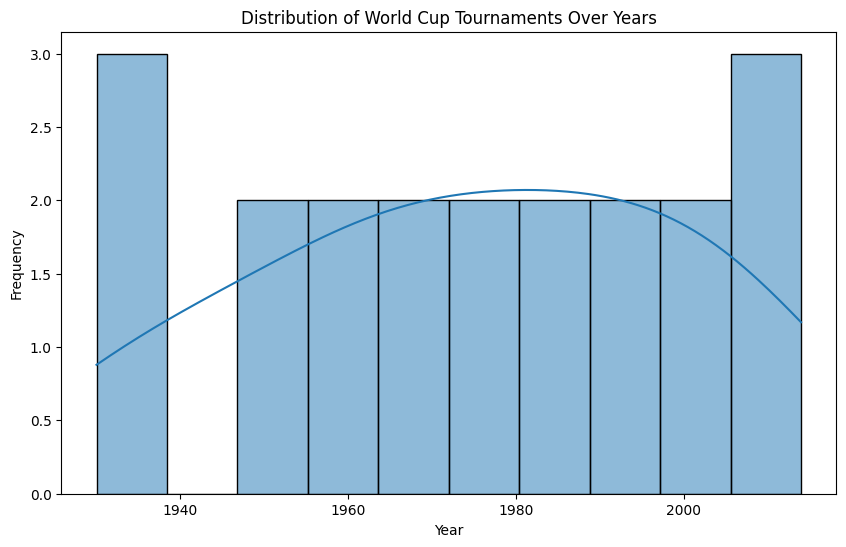

In [ ]:
# Distribution of World Cup tournaments over the years
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(world_cups_df['Year'], bins=10, kde=True)
plt.title('Distribution of World Cup Tournaments Over Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# Top Winners and Runners-Up
top_winners = world_cups_df['Winner'].value_counts().head(5)
top_runners_up = world_cups_df['Runners-Up'].value_counts().head(5)
print("Top Winners:")
print(top_winners)
print("\nTop Runners-Up:")
print(top_runners_up)


Top Winners:
Winner
Brazil        5
Italy         4
Germany FR    3
Uruguay       2
Argentina     2
Name: count, dtype: int64

Top Runners-Up:
Runners-Up
Argentina         3
Germany FR        3
Netherlands       3
Czechoslovakia    2
Hungary           2
Name: count, dtype: int64


In [ ]:
print(matches_df.columns)


Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials'],
      dtype='object')


Exploratory Data Analysis for matches_df


In [ ]:
# Summary statistics for numerical columns
summary_stats_matches = matches_df.describe()
print("Summary Statistics for Matches DataFrame:")
print(summary_stats_matches)


Summary Statistics for Matches DataFrame:
              Year  Home Team Goals  Away Team Goals     Attendance  \
count   852.000000       852.000000       852.000000     850.000000   
mean   1985.089202         1.811033         1.022300   45164.800000   
std      22.448825         1.610255         1.087573   23485.249247   
min    1930.000000         0.000000         0.000000    2000.000000   
25%    1970.000000         1.000000         0.000000   30000.000000   
50%    1990.000000         2.000000         1.000000   41579.500000   
75%    2002.000000         3.000000         2.000000   61374.500000   
max    2014.000000        10.000000         7.000000  173850.000000   

       Half-time Home Goals  Half-time Away Goals       RoundID       MatchID  
count            852.000000            852.000000  8.520000e+02  8.520000e+02  
mean               0.708920              0.428404  1.066177e+07  6.134687e+07  
std                0.937414              0.691252  2.729613e+07  1.110572e+08 

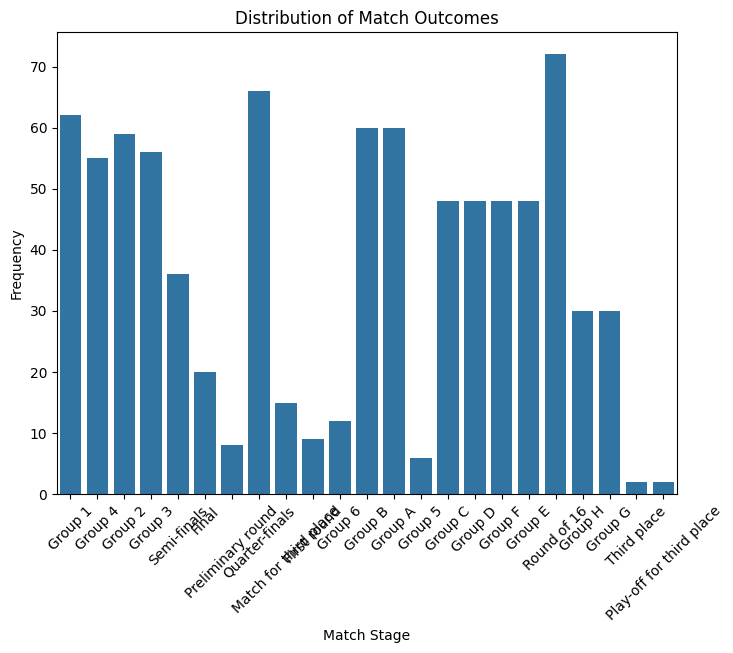

In [ ]:
# Distribution of match outcomes based on the 'Stage' column
plt.figure(figsize=(8, 6))
sns.countplot(x=matches_df['Stage'])  # Use 'Stage' column to represent match outcomes
plt.title('Distribution of Match Outcomes')
plt.xlabel('Match Stage')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()



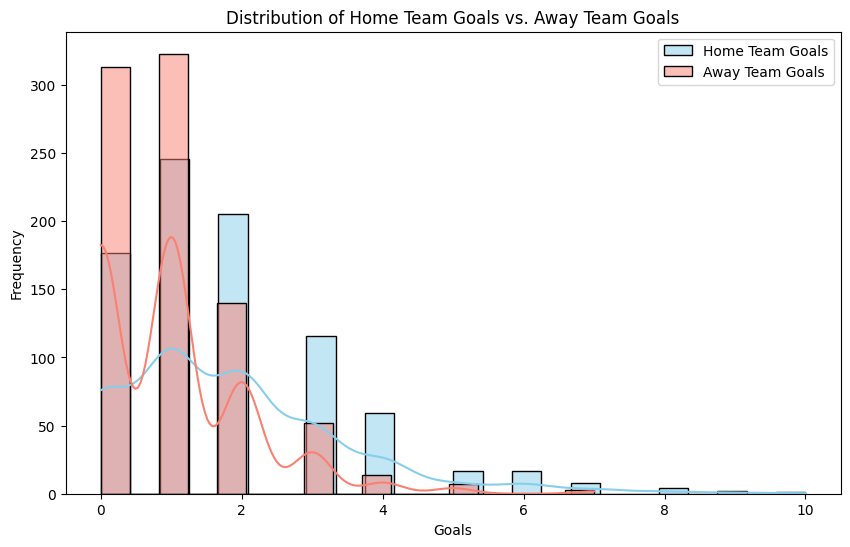

In [ ]:
# Distribution of Home Team Goals vs. Away Team Goals
plt.figure(figsize=(10, 6))
sns.histplot(data=matches_df, x='Home Team Goals', label='Home Team Goals', color='skyblue', kde=True)
sns.histplot(data=matches_df, x='Away Team Goals', label='Away Team Goals', color='salmon', kde=True)
plt.title('Distribution of Home Team Goals vs. Away Team Goals')
plt.xlabel('Goals')
plt.ylabel('Frequency')
plt.legend()
plt.show()


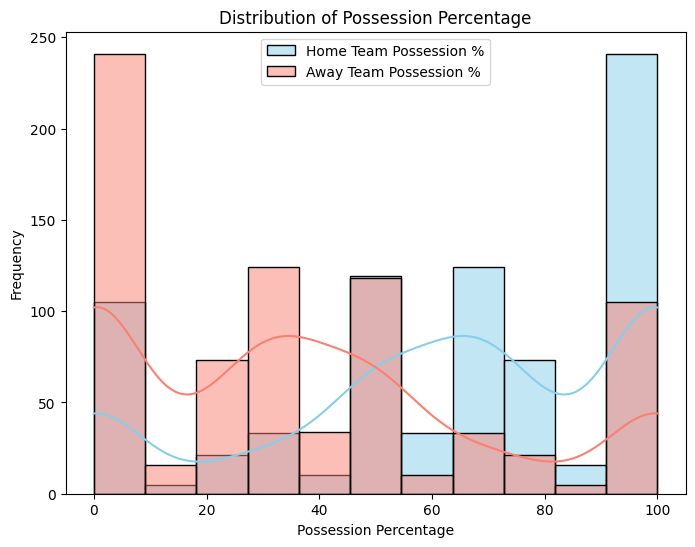

In [ ]:
# Calculate possession percentage for home team
matches_df['Home Possession %'] = (matches_df['Home Team Goals'] / (matches_df['Home Team Goals'] + matches_df['Away Team Goals'])) * 100

# Calculate possession percentage for away team
matches_df['Away Possession %'] = (matches_df['Away Team Goals'] / (matches_df['Home Team Goals'] + matches_df['Away Team Goals'])) * 100

# Plot the distribution of possession percentages
plt.figure(figsize=(8, 6))
sns.histplot(data=matches_df, x='Home Possession %', label='Home Team Possession %', color='skyblue', kde=True)
sns.histplot(data=matches_df, x='Away Possession %', label='Away Team Possession %', color='salmon', kde=True)
plt.title('Distribution of Possession Percentage')
plt.xlabel('Possession Percentage')
plt.ylabel('Frequency')
plt.legend()
plt.show()



Match analysis
1. . Explore Match Outcomes

In [ ]:
# Display column names in the matches_df DataFrame
print(matches_df.columns)


Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials',
       'Home Possession %', 'Away Possession %'],
      dtype='object')


In [ ]:
# Analyze match outcomes
match_outcomes = matches_df['Win conditions'].value_counts()
print("Match Outcomes:")
print(match_outcomes)


Match Outcomes:
Win conditions
                                                 787
Italy win after extra time                         5
Germany win after extra time                       4
Argentina win after extra time                     4
Belgium win after extra time                       3
Win on Golden Goal                                 3
England win after extra time                       3
Brazil win on penalties (3 - 2)                    3
Netherlands win on penalties (4 - 3)               2
Argentina win on penalties (2 - 4)                 2
France win after extra time                        2
France win on penalties (3 - 4)                    2
Costa Rica win on penalties (5 - 3)                2
 win on penalties (5 - 4)                          1
Germany FR win on penalties (4 - 1)                1
Brazil win after extra time                        1
Czechoslovakia win after extra time                1
Hungary win after extra time                       1
Spain win after

2. Calculate Match Statistics

In [ ]:
# Calculate total goals scored by each team
total_goals_home_team = matches_df.groupby('Home Team Name')['Home Team Goals'].sum()
total_goals_away_team = matches_df.groupby('Away Team Name')['Away Team Goals'].sum()

# Calculate average possession percentage for each team
average_possession_home_team = matches_df.groupby('Home Team Name')['Home Possession %'].mean()
average_possession_away_team = matches_df.groupby('Away Team Name')['Away Possession %'].mean()

# Combine the calculated statistics into a DataFrame
match_statistics = pd.DataFrame({
    'Total Goals Home Team': total_goals_home_team,
    'Total Goals Away Team': total_goals_away_team,
    'Average Possession % Home Team': average_possession_home_team,
    'Average Possession % Away Team': average_possession_away_team
})

# Display the calculated match statistics
print("Match Statistics by Team:")
print(match_statistics)


Match Statistics by Team:
                            Total Goals Home Team  Total Goals Away Team  \
Algeria                                       5.0                    9.0   
Angola                                        0.0                    1.0   
Argentina                                   111.0                   22.0   
Australia                                     7.0                    4.0   
Austria                                      31.0                   12.0   
...                                           ...                    ...   
rn">Bosnia and Herzegovina                    3.0                    1.0   
rn">Republic of Ireland                       2.0                    8.0   
rn">Serbia and Montenegro                     0.0                    2.0   
rn">Trinidad and Tobago                       0.0                    0.0   
rn">United Arab Emirates                      0.0                    2.0   

                            Average Possession % Home Team  \

3. Relationship between Match Statistics and Outcomes

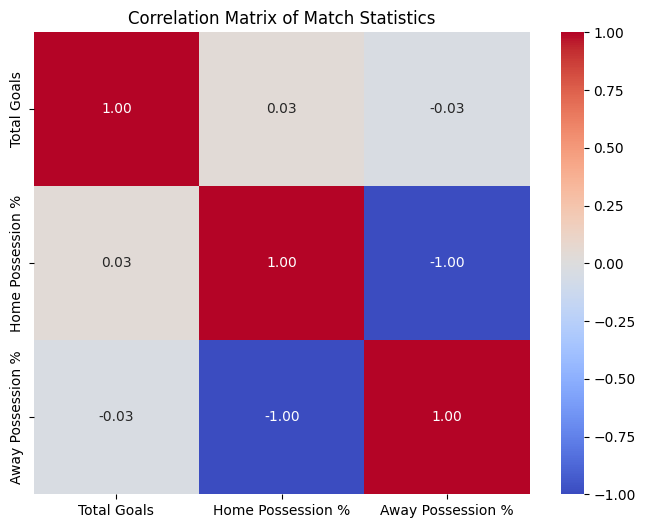

In [ ]:


# Calculate 'Total Goals' as the sum of 'Home Team Goals' and 'Away Team Goals'
matches_df['Total Goals'] = matches_df['Home Team Goals'] + matches_df['Away Team Goals']

# Calculate correlation matrix
correlation_matrix = matches_df[['Total Goals', 'Home Possession %', 'Away Possession %']].corr()

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Match Statistics')
plt.show()


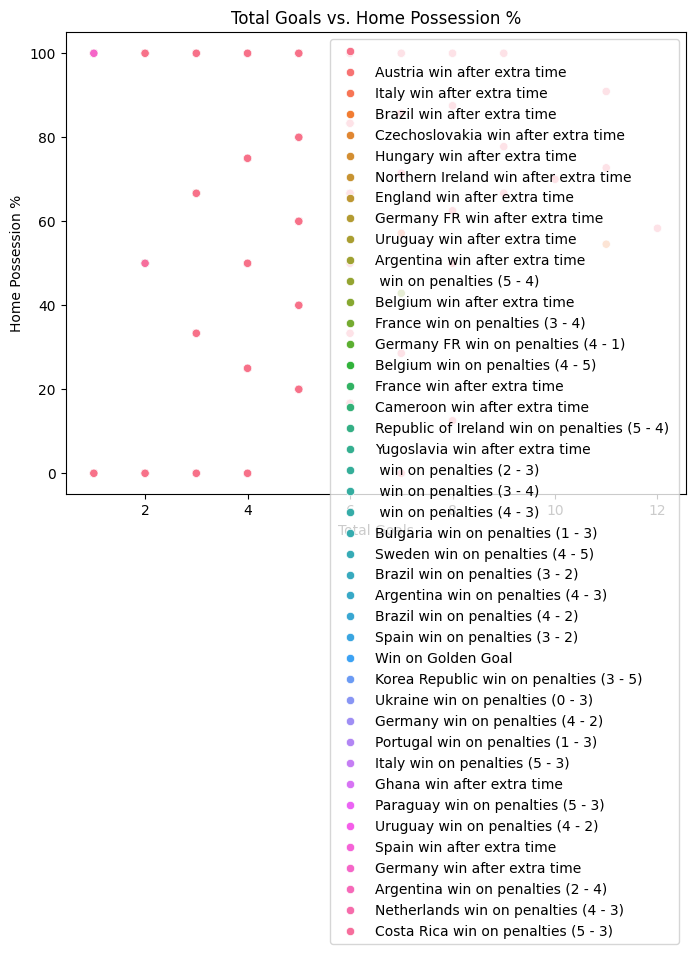

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Total Goals vs. Total Possession %
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Goals', y='Home Possession %', data=matches_df, hue='Win conditions')
plt.title('Total Goals vs. Home Possession %')
plt.xlabel('Total Goals')
plt.ylabel('Home Possession %')
plt.legend()
plt.show()


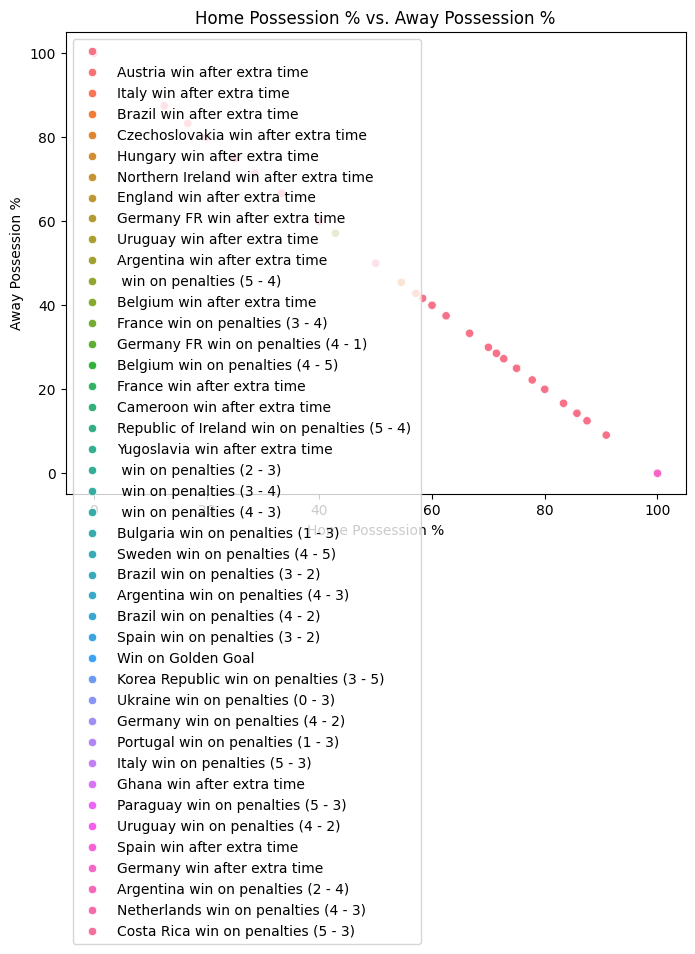

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Home Possession % vs. Away Possession %
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Home Possession %', y='Away Possession %', data=matches_df, hue='Win conditions')
plt.title('Home Possession % vs. Away Possession %')
plt.xlabel('Home Possession %')
plt.ylabel('Away Possession %')
plt.legend()
plt.show()


 Key Factors Influencing Wins


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Assuming you have the relevant data loaded into a DataFrame called 'matches_df'

# Step 1: Identify Key Factors
# We'll consider 'Home Team Goals', 'Away Team Goals', 'Home Possession %', and 'Away Possession %'

# Step 2: Conduct Statistical Analysis
# Prepare the data
X = matches_df[['Home Team Goals', 'Away Team Goals', 'Home Possession %', 'Away Possession %']]
matches_df['Home Advantage'] = (matches_df['Win conditions'] == 'Win').astype(int)  # Create 'Home Advantage' feature
y = matches_df['Home Advantage']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a pipeline to handle missing values and train the model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with mean
    ('regressor', LinearRegression())             # Linear regression model
])

# Train the linear regression model
pipeline.fit(X_train, y_train)

# Predict outcomes on the test set
y_pred = pipeline.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)



Mean Squared Error: 0.0


              Factor  Coefficient
0    Home Team Goals          0.0
1    Away Team Goals          0.0
2  Home Possession %          0.0
3  Away Possession %          0.0


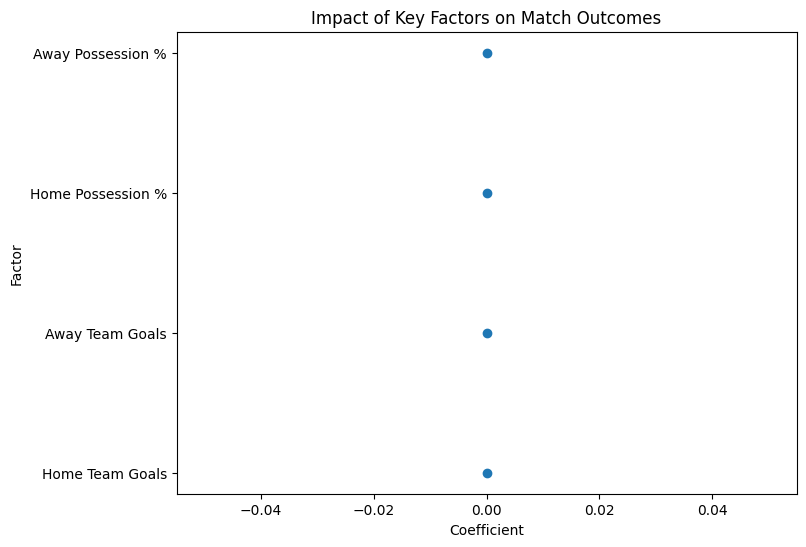

In [ ]:
# Retrieve coefficients from the trained linear regression model
coefficients = pd.DataFrame({'Factor': X.columns, 'Coefficient': pipeline.named_steps['regressor'].coef_})

# Print the coefficients
print(coefficients)

# Plot the coefficients without using a bar plot
plt.figure(figsize=(8, 6))
plt.scatter(coefficients['Coefficient'], coefficients['Factor'])
plt.title('Impact of Key Factors on Match Outcomes')
plt.xlabel('Coefficient')
plt.ylabel('Factor')
plt.show()


In [ ]:
# Print column names of the DataFrame
print(matches_df.columns)



Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials',
       'Home Win'],
      dtype='object')


In [ ]:
#Player performance Analysis
players_df= pd.read_csv("/content/WorldCupPlayers.csv")

In [ ]:
players_df.head()

,RoundID,MatchID,Team Initials,Coach Name,Line-up,Shirt Number,Player Name,Position,Event
0,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Alex THEPOT,GK,NaN
1,201,1096,MEX,LUQUE Juan (MEX),S,0,Oscar BONFIGLIO,GK,NaN
2,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Marcel LANGILLER,NaN,G40'
3,201,1096,MEX,LUQUE Juan (MEX),S,0,Juan CARRENO,NaN,G70'
4,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Ernest LIBERATI,NaN,NaN


In [ ]:
print(players_df.columns)

Index(['RoundID', 'MatchID', 'Team Initials', 'Coach Name', 'Line-up',
       'Shirt Number', 'Player Name', 'Position', 'Event'],
      dtype='object')


In [ ]:
print("\nInconsistencies in players_df:")
print(players_df.isnull().sum())


Inconsistencies in players_df:
RoundID          0
MatchID          0
Team Initials    0
Coach Name       0
Line-up          0
Shirt Number     0
Player Name      0
Position         0
Event            0
dtype: int64


In [ ]:
# Example of extracting goals scored by players
players_df['Goals'] = players_df['Event'].apply(lambda x: 1 if 'G' in str(x) else 0)
players_df['Assists'] = players_df['Event'].apply(lambda x: 1 if 'A' in str(x) else 0)

# Check the updated DataFrame
print(players_df.head())


     RoundID  MatchID Team Initials                 Coach Name Line-up  \
35       201     1090           USA           MILLAR Bob (USA)       S   
74       201     1093           BRA  DE CARVALHO Pindaro (BRA)       S   
113      201     1098           PER        BRU Francisco (ESP)       S   
415      201     1091           BRA  DE CARVALHO Pindaro (BRA)       S   
468      201     1089           PAR   DURAND LAGUNA Jose (ARG)       S   

     Shirt Number       Player Name Position      Event  Goals  Assists  
35              0        Tom FLORIE        C       G45'      1        0  
74              0         PREGUINHO        C       G62'      1        0  
113             0   Placido GALINDO        C       R70'      0        0  
415             0         PREGUINHO        C  G67' G83'      1        0  
468             0  Luis VARGAS PENA        C       G40'      1        0  


In [ ]:
# Aggregate player performance
player_performance = players_df.groupby('Player Name').agg({
    'Goals': 'sum',
    'Assists': 'sum',
    'MatchID': 'nunique'  # Number of matches played
}).reset_index()

# Add a column for average goals per match
player_performance['Goals per Match'] = player_performance['Goals'] / player_performance['MatchID']

# Display the top performers
top_performers = player_performance.sort_values(by='Goals', ascending=False).head(10)
print(top_performers)


               Player Name  Goals  Assists  MatchID  Goals per Match
319             Uwe SEELER      5        0        5         1.000000
114          Gyorgy SAROSI      4        0        4         1.000000
141          Jan CEULEMANS      4        0        5         0.800000
64          Diego MARADONA      4        0        7         0.571429
198                  MESSI      3        0        3         1.000000
260                RUIZ B.      3        0        3         1.000000
90           Ferenc PUSKAS      3        0        3         1.000000
172        Kazimierz DEYNA      3        0        4         0.750000
125          Hans SCHAEFER      3        0        3         1.000000
170  Karl-Heinz RUMMENIGGE      3        0        8         0.375000


<ipython-input-56-f5c47d9eb2c0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Goals', y='Player Name', data=top_performers, palette='viridis')


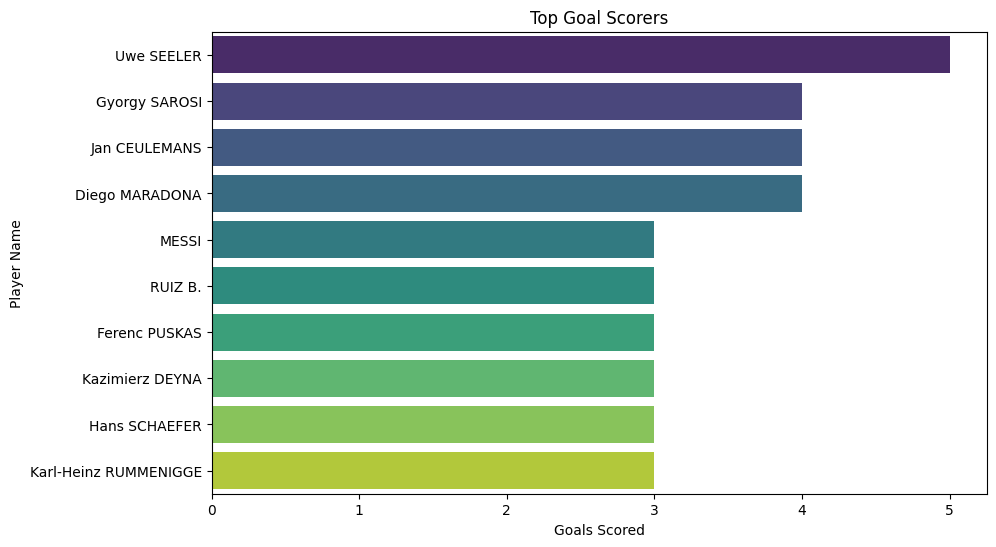

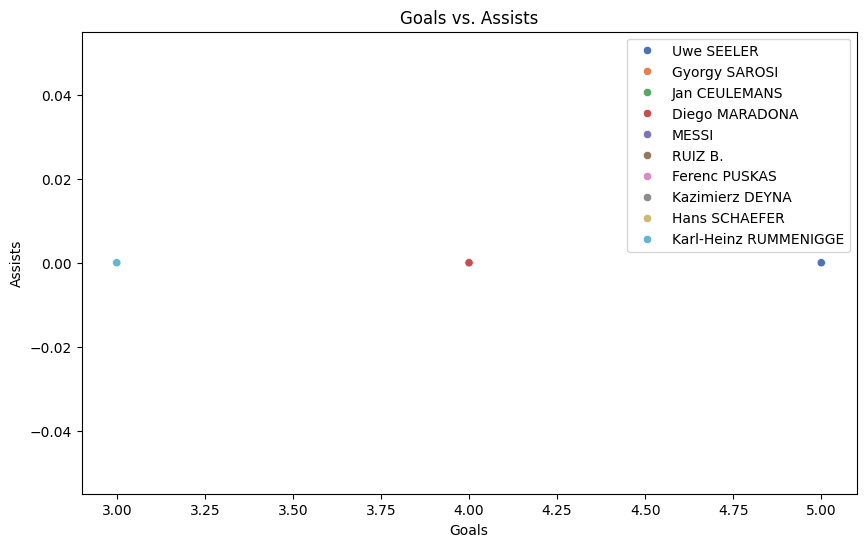

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot for top goal scorers
plt.figure(figsize=(10, 6))
sns.barplot(x='Goals', y='Player Name', data=top_performers, palette='viridis')
plt.title('Top Goal Scorers')
plt.xlabel('Goals Scored')
plt.ylabel('Player Name')
plt.show()

# Scatter plot for goals vs. assists
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Goals', y='Assists', hue='Player Name', data=top_performers, palette='deep')
plt.title('Goals vs. Assists')
plt.xlabel('Goals')
plt.ylabel('Assists')
plt.legend(loc='upper right')
plt.show()


MACHINE LEARNING MODEL FOR FUTURE PREDICTION


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


matches_df = pd.read_csv('WorldCupMatches.csv')

matches_df['Home Win'] = (matches_df['Home Team Goals'] > matches_df['Away Team Goals']).astype(int)
X = matches_df[['Home Team Goals', 'Away Team Goals', 'Half-time Home Goals', 'Half-time Away Goals']]
y = matches_df['Home Win']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
imputer = SimpleImputer(strategy='mean')

In [ ]:
dt_pipeline = Pipeline([
    ('imputer', imputer),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [ ]:
# Train the Decision Tree model
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
# @title Default title text
# Predict outcomes on the test set
y_pred_dt = dt_pipeline.predict(X_test)


In [ ]:
#Evaluate the model
# Evaluate Decision Tree model
print("Decision Tree Model")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Model
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       801
           1       1.00      1.00      1.00       114

    accuracy                           1.00       915
   macro avg       1.00      1.00      1.00       915
weighted avg       1.00      1.00      1.00       915

Confusion Matrix:
 [[801   0]
 [  0 114]]


In [ ]:
# Making Predictions for new data (Example)
# Assuming new_data
new_data = pd.DataFrame({
    'Home Team Goals': [1, 2],
    'Away Team Goals': [1, 1],
    'Half-time Home Goals': [1, 1],
    'Half-time Away Goals': [1, 0]
})


In [ ]:
# Predict outcomes for new data using the trained Decision Tree model
new_data_imputed = imputer.transform(new_data)
dt_predictions = dt_pipeline.named_steps['classifier'].predict(new_data_imputed)

In [ ]:
print("Decision Tree Predictions for new data:", dt_predictions)

Decision Tree Predictions for new data: [0 1]


In [ ]:
# Define a pipeline to handle missing values and train the Logistic Regression model
lr_pipeline = Pipeline([
    ('imputer', imputer),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the Logistic Regression model
lr_pipeline.fit(X_train, y_train)

# Predict outcomes on the test set
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate Logistic Regression model
print("Logistic Regression Model")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Model
Accuracy: 0.9704918032786886
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       801
           1       1.00      0.76      0.87       114

    accuracy                           0.97       915
   macro avg       0.98      0.88      0.92       915
weighted avg       0.97      0.97      0.97       915

Confusion Matrix:
 [[801   0]
 [ 27  87]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load the historical FIFA World Cup matches data
matches_df = pd.read_csv('WorldCupMatches.csv')

# Prepare the data
matches_df['Winner'] = matches_df.apply(lambda row: row['Home Team Name'] if row['Home Team Goals'] > row['Away Team Goals'] else row['Away Team Name'], axis=1)
winners_df = matches_df[['Year', 'Winner']].dropna().drop_duplicates()



In [ ]:
# Create feature dataframe
features_list = []

for year in range(1934, 2018, 4):  # Assuming the historical data includes years from 1930 to 2014
    previous_year = year - 4
    previous_winner = winners_df[winners_df['Year'] == previous_year]['Winner'].values
    previous_winner = previous_winner[0] if len(previous_winner) > 0 else None

    teams_current_year = matches_df[matches_df['Year'] == year]['Home Team Name'].unique().tolist()
    teams_current_year.extend(matches_df[matches_df['Year'] == year]['Away Team Name'].unique().tolist())
    teams_current_year = list(set(teams_current_year))

    for team in teams_current_year:
        goals_scored = matches_df[(matches_df['Year'] == previous_year) & ((matches_df['Home Team Name'] == team) | (matches_df['Away Team Name'] == team))]['Home Team Goals'].sum()
        goals_conceded = matches_df[(matches_df['Year'] == previous_year) & ((matches_df['Home Team Name'] == team) | (matches_df['Away Team Name'] == team))]['Away Team Goals'].sum()

        features_list.append({
            'Year': year,
            'Team': team,
            'Goals_Scored': goals_scored,
            'Goals_Conceded': goals_conceded,
            'Previous_Winner': 1 if team == previous_winner else 0
        })

features_df = pd.DataFrame(features_list)

In [ ]:
# Prepare target variable
winners_2014 = winners_df[winners_df['Year'] == 2014]['Winner'].unique()
features_df['Is_Winner'] = features_df.apply(lambda row: 1 if row['Year'] == 2018 and row['Team'] in winners_2014 else 0, axis=1)

In [ ]:
# Select features and target
X = features_df[['Goals_Scored', 'Goals_Conceded', 'Previous_Winner']]
y = features_df['Is_Winner']


In [ ]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Define and train the model (Random Forest Classifier)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with mean
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))  # Random Forest Classifier
])


In [ ]:
# Train the Random Forest model
pipeline.fit(X_train, y_train)

# Predict outcomes on the test set
y_pred = pipeline.predict(X_test)


In [ ]:
# Evaluate the Random Forest model
print("Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest Classifier
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        83

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83

Confusion Matrix:
 [[83]]


In [ ]:
# Predict the 2018 FIFA World Cup winner
teams_2018 = matches_df[matches_df['Year'] == 2018]['Home Team Name'].unique().tolist()
teams_2018.extend(matches_df[matches_df['Year'] == 2018]['Away Team Name'].unique().tolist())
teams_2018 = list(set(teams_2018))

In [ ]:
predicted_winner = None
max_proba = 0
for team in teams_2018:
    goals_scored = matches_df[(matches_df['Year'] == 2014) & ((matches_df['Home Team Name'] == team) | (matches_df['Away Team Name'] == team))]['Home Team Goals'].sum()
    goals_conceded = matches_df[(matches_df['Year'] == 2014) & ((matches_df['Home Team Name'] == team) | (matches_df['Away Team Name'] == team))]['Away Team Goals'].sum()

    proba = pipeline.predict_proba([[goals_scored, goals_conceded, 1 if team in winners_2014 else 0]])[0][1]

    if proba > max_proba:
        max_proba = proba
        predicted_winner = team

print("Predicted winner of the 2018 FIFA World Cup:", predicted_winner)

Predicted winner of the 2018 FIFA World Cup: None
